# LGBMForecastModel — LightGBM Classification Model

This section implements the **LGBMForecastModel**, which is used to predict the **next-day direction of WTI crude oil prices**.

The forecasting task is formulated as a **binary classification problem**, where the model predicts whether the oil price will move **up (1)** or **down (0)** on the next trading day.

LightGBM is a gradient boosting framework based on decision trees. It builds the model sequentially by fitting each new tree to the errors of the previous ensemble. This allows the model to capture **nonlinear relationships and complex interactions** between macroeconomic indicators and historical price patterns.

Compared with linear models, LightGBM is more flexible in modeling nonlinear decision boundaries. Compared with a single decision tree, it is generally more stable and achieves better predictive performance through boosting.

The model uses the same input features as the previous models in this project:

- **31 macroeconomic variables** derived from the FRED-MD dataset  
- **30 lagged daily WTI prices**, representing the most recent market dynamics  

Together these variables form a **61-dimensional feature vector** used to predict the next-day price direction.

Using the same feature set across all models ensures that performance differences are mainly driven by the modeling approach rather than differences in input construction.

In [ ]:
import glob
import os
from google.colab import drive

# Mount Google Drive to access files
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# imports all libraries used in the workflow.
!pip install lightgbm
from lightgbm import LGBMClassifier
from __future__ import annotations

import warnings
from abc import ABC, abstractmethod
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

## STEP 1 — Data Preprocessing

### 1. EXPLAINING EACH INPUT FILE / FOLDER
1) wti_daily_master.csv：This file contains the daily WTI crude oil closing price series from 1999-06-02 to 2025-12-31.
2) vintages_99_14/, vintages_15_24/: The two folders contain monthly FRED-MD vintage files for the earlier historical period. Each file corresponds to a monthly release snapshot. These files are used to recover macro values that would have been available at the time.
3) vintages_25.csv: This file is used for the 2025 macro snapshot. It helps extend the same delayed-macro logic into the 2025 test period.

THE FILE LINK:

https://drive.google.com/drive/folders/1csLhZIlSZQWi01ZRO7vt1NaCb7_i_9Bn?usp=sharing

In [ ]:
PROJECT_DIR = Path("/content/drive/MyDrive/VIP_Energy_Market").resolve()

# File / folder locations
OIL_PATH = PROJECT_DIR / "wti_daily_master.csv"
VINTAGE_DIRS = [
    PROJECT_DIR / "vintages_99_14",
    PROJECT_DIR / "vintages_15_24",
]
VINTAGE_FILE_25 = PROJECT_DIR / "vintages_25.csv"

# Output locations
OUT_ALIGNED = PROJECT_DIR / "final_aligned_dataset.csv"
OUT_FIG_DIR = PROJECT_DIR / "figures"
OUT_MODEL = PROJECT_DIR / "lgbm_model.pkl"

# Create figures folder if it does not already exist.
OUT_FIG_DIR.mkdir(parents=True, exist_ok=True)

### 2. Required macro variables
MACRO_31: List[str] = [
    "RPI", "W875RX1", "CMRMTSPLx", "IPFPNSS", "USWTRADE", "USTRADE", "BUSLOANS",
    "CONSPI", "S&P 500", "S&P PE ratio", "FEDFUNDS", "TB3MS", "TB6MS",
    "GS1", "GS5", "GS10", "AAA", "BAA",
    "TB3SMFFM", "TB6SMFFM", "T1YFFM", "T5YFFM", "T10YFFM", "AAAFFM", "BAAFFM",
    "EXSZUSx", "EXJPUSx", "EXUSUKx", "EXCAUSx", "PPICMM", "UMCSENTx",
]

In [ ]:
# Required macro variables
MACRO_31: List[str] = [
    "RPI", "W875RX1", "CMRMTSPLx", "IPFPNSS", "USWTRADE", "USTRADE", "BUSLOANS",
    "CONSPI", "S&P 500", "S&P PE ratio", "FEDFUNDS", "TB3MS", "TB6MS",
    "GS1", "GS5", "GS10", "AAA", "BAA",
    "TB3SMFFM", "TB6SMFFM", "T1YFFM", "T5YFFM", "T10YFFM", "AAAFFM", "BAAFFM",
    "EXSZUSx", "EXJPUSx", "EXUSUKx", "EXCAUSx", "PPICMM", "UMCSENTx",
]

### 3. T-CODE TRANSFORMATIONS FOR FRED-MD
Each FRED-MD variable comes with a transformation code (T-code) that tells us how to transform the monthly series into a more stationary representation.

Why this step is necessary: The instructor explicitly asked us to apply the correct stationarity transformation.

T-code definitions used here:

1 = level

2 = first difference

3 = second difference

4 = log

5 = log first difference

6 = log second difference

In [ ]:
def _safe_log(series: pd.Series) -> pd.Series:
    """
    Apply a safe natural logarithm.
    Non-positive values are converted to NaN before log is applied.
    """
    series = pd.to_numeric(series, errors="coerce")
    series = series.where(series > 0)
    return np.log(series)

def apply_tcode(series: pd.Series, code: int) -> pd.Series:
    """
    Apply a FRED-MD transformation code to one monthly macro series.
    """
    s = pd.to_numeric(series, errors="coerce")

    if code == 1:
        return s
    if code == 2:
        return s.diff()
    if code == 3:
        return s.diff().diff()
    if code == 4:
        return _safe_log(s)
    if code == 5:
        return _safe_log(s).diff()
    if code == 6:
        return _safe_log(s).diff().diff()

    # Fallback: leave unchanged if code is missing or unexpected.
    return s

### 4. LOADING MONTHLY VINTAGE FILES
This step defines helper functions for finding a monthly vintage file and reading it.

Why this is needed: Macro data are not stored in one simple continuous daily file. Instead, the project uses vintage snapshots. Therefore, we must:

1) find the correct vintage release file

2) read its monthly data

3) apply T-code transformations

This step keeps the vintage logic separate from the later daily alignment logic, which makes the notebook easier to follow.

In [ ]:
def find_vintage_file_for_release_month(
    vintage_dirs: List[Path],
    release_month: pd.Timestamp
) -> Optional[Path]:
    """
    Find the vintage CSV matching a release month in YYYY-MM.csv format.
    """
    filename = f"{release_month.year:04d}-{release_month.month:02d}.csv"
    for folder in vintage_dirs:
        candidate = folder / filename
        if candidate.exists():
            return candidate
    return None

def load_and_transform_vintage(vintage_csv: Path) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Load one vintage CSV and apply the T-code transformation to each macro column.

    Returns
    -------
    transformed_monthly_data : pd.DataFrame
        Monthly macro data after T-code transformation.
    tcodes : pd.Series
        The transformation code row extracted from the file.
    """
    raw = pd.read_csv(vintage_csv)

    # The first row stores the transformation codes.
    tcodes = raw.iloc[0].copy()

    # Remaining rows store actual monthly data.
    data = raw.drop(index=0).reset_index(drop=True)

    # Some files may use 'sasdate', others may use 'date'.
    date_col = None
    for candidate in ["sasdate", "date"]:
        if candidate in data.columns:
            date_col = candidate
            break

    if date_col is None:
        raise ValueError(f"No date column found in {vintage_csv}")

    # Parse and sort the monthly dates.
    data[date_col] = pd.to_datetime(data[date_col], errors="coerce")
    data = data.sort_values(date_col).reset_index(drop=True)

    # Apply the correct T-code to each non-date column.
    for col in data.columns:
        if col == date_col:
            continue
        try:
            code = int(float(tcodes[col]))
        except Exception:
            continue
        data[col] = apply_tcode(data[col], code)

    # This forward fill only handles NaN values introduced by differencing/logging.
    data = data.replace([np.inf, -np.inf], np.nan).ffill()

    # Standardize the date column name.
    if date_col != "sasdate":
        data = data.rename(columns={date_col: "sasdate"})

    return data, tcodes

### 5. BUILDING THE ALIGNED DAILY DATASET

Goal: Build one daily table where each daily price observation is paired with the correct macro values that would have been available at that time.
For every calendar month M:
- use macro values from month M-1
- assign those previous-month macro values to every day within month M

Example
- all days in February receive January macro values


FRED-MD Macro Data Alignment & Vintage Logic (Handling Reporting Delay)

A critical challenge in financial forecasting is ensuring that the model only uses information that was actually available at the time of prediction. Macroeconomic data (FRED-MD) is typically released with a significant reporting delay (usually one month).

To ensure a leakage-free workflow, we implement the following Vintage Logic:

1. Addressing the Reporting Delay

Standard FRED-MD files are "finalized" datasets that contain revised values. Using them directly for daily prediction would introduce Data Leakage.

The Rule: To predict price direction on day t in month M, we only use macro data from month M−1.

Implementation: For every calendar day in February, the model is only allowed to "see" the macroeconomic snapshot released in January (which describes the economy as of December or earlier).

2. Monthly-to-Daily Frequency Alignment

We use a Forward-Filling approach to align monthly macro variables with daily WTI closing prices:

Every trading day within a specific month is assigned the exact same macro values from the previous month’s vintage snapshot.

This ensures that no "future" macro information from the current month is used to predict daily price movements.

3. Vintage Snapshot Selection

Instead of using a single continuous file, our code iterates through monthly Vintage CSVs:

For each month in the timeline, the find_vintage_file_for_release_month function locates the specific CSV file that was the "latest available" at that time.

This mimics the real-world environment of a trader who only has access to the data released up to that specific date.

In [ ]:
def build_aligned_daily_dataset(
    oil_daily_csv: Path,
    vintage_dirs: List[Path],
    vintage_2025_csv: Optional[Path],
    out_csv: Path,
) -> pd.DataFrame:
    """
    Build a leakage-safe daily dataset by aligning monthly macro data to daily prices.

    Output columns
    --------------
    - Date
    - Price
    - 31 macro variables
    """
    # Load daily oil price data.
    oil_df = pd.read_csv(oil_daily_csv, parse_dates=["Date"])
    oil_df = oil_df.sort_values("Date").reset_index(drop=True)

    # Standardize the price column name if necessary.
    if "Price" not in oil_df.columns:
        for candidate in ["Close", "close", "WTI", "wti", "Adj Close", "Adj_Close"]:
            if candidate in oil_df.columns:
                oil_df = oil_df.rename(columns={candidate: "Price"})
                break

    if "Price" not in oil_df.columns:
        raise ValueError("Could not find a daily price column in the oil CSV.")

    # Add calendar month for monthly grouping.
    oil_df["month"] = oil_df["Date"].dt.to_period("M")
    unique_months = sorted(oil_df["month"].unique())

    aligned_chunks: List[pd.DataFrame] = []
    macro25_lookup = None

    # Optional 2025 macro snapshot support.
    if vintage_2025_csv is not None and Path(vintage_2025_csv).exists():
        v25 = pd.read_csv(vintage_2025_csv)

        if "date" not in v25.columns:
            if "sasdate" in v25.columns:
                v25 = v25.rename(columns={"sasdate": "date"})
            else:
                raise ValueError("vintages_25.csv must contain 'date' or 'sasdate'.")

        v25["date"] = pd.to_datetime(v25["date"], errors="coerce")
        v25["month"] = v25["date"].dt.to_period("M")
        macro25_lookup = v25.set_index("month")

    # Process one calendar month at a time.
    for month_now in unique_months:
        # Keep only the daily rows from the current month.
        current_month_rows = oil_df.loc[
            oil_df["month"] == month_now, ["Date", "Price"]
        ].copy()

        if current_month_rows.empty:
            continue

        # Enforce the one-month reporting delay.
        # Current month M must use macro values from month M-1.
        macro_month = month_now - 1
        macro_values: Optional[pd.Series] = None

        # If we are in 2025 and a dedicated macro file exists, use it.
        if macro25_lookup is not None and month_now.year >= 2025:
            if macro_month in macro25_lookup.index:
                row = macro25_lookup.loc[macro_month]
                if isinstance(row, pd.DataFrame):
                    row = row.iloc[-1]
                macro_values = row

        # Otherwise, recover the macro values from the appropriate vintage file.
        if macro_values is None:
            release_month_ts = pd.Timestamp(month_now.start_time)
            vintage_file = find_vintage_file_for_release_month(vintage_dirs, release_month_ts)

            if vintage_file is None:
                # Skip this month if the corresponding release file is not found.
                continue

            transformed_vintage, _ = load_and_transform_vintage(vintage_file)

            # Retrieve the row for the previous macro month.
            row_match = transformed_vintage[
                transformed_vintage["sasdate"].dt.to_period("M") == macro_month
            ]

            if not row_match.empty:
                macro_values = row_match.iloc[-1]
            else:
                # Conservative fallback: use the latest available row in that vintage file.
                macro_values = transformed_vintage.iloc[-1]

        # Attach the 31 macro variables to every daily row in the current month.
        for col in MACRO_31:
            current_month_rows[col] = macro_values[col] if col in macro_values.index else np.nan

        aligned_chunks.append(current_month_rows)

    # Combine all months into one final daily dataset.
    final_df = pd.concat(aligned_chunks, ignore_index=True)
    final_df = final_df.sort_values("Date").reset_index(drop=True)

    # Basic cleaning.
    final_df = final_df.dropna(subset=["Price"])
    final_df = final_df.ffill()

    # Save the aligned dataset for reuse.
    final_df.to_csv(out_csv, index=False)
    return final_df

## STEP 2 — FEATURE ENGINEERING
This step creates the actual model inputs and target.

Input specification (detailed)

The final feature vector contains:
- 31 macro variables
- 30 lagged daily closing prices:
Price_Lag_1, Price_Lag_2, ..., Price_Lag_30

Total feature count
- 31 + 30 = 61 input features

Target definition
- Target_Direction_t = 1 if Price_t > Price_(t-1), else 0

At time t, the model only sees:
- daily prices from t-1 backward to t-30
- macro variables that correspond to the previous month

Therefore, no future information is included.

In [ ]:
# Rolling lookback length required by the instructions
LOOKBACK_DAYS = 30
def add_price_lags_and_target(df: pd.DataFrame, lookback: int = LOOKBACK_DAYS) -> pd.DataFrame:
    """
    Create 30 lagged closing-price features and a binary direction target.
    """
    df = df.sort_values("Date").reset_index(drop=True).copy()

    # Create lagged price features.
    for lag in range(1, lookback + 1):
        df[f"Price_Lag_{lag}"] = df["Price"].shift(lag)

    # Create binary target for next-day direction relative to the previous day.
    df["Target_Direction"] = (df["Price"] > df["Price"].shift(1)).astype(int)

    # Drop rows that do not yet have a full 30-day history.
    lag_cols = [f"Price_Lag_{lag}" for lag in range(1, lookback + 1)]
    df = df.dropna(subset=lag_cols)

    # Drop rows missing any macro variable.
    df = df.dropna(subset=MACRO_31)

    return df

## STEP 3 — TIME-BASED TRAIN / VALIDATION / TEST SPLITS
This step partitions the dataset chronologically.

Why this is important: Financial time series must never be shuffled, because doing so would mix past and future observations and invalidate the evaluation.

What this step produces:
- a training set used for model fitting and hyperparameter search
- a validation set used for out-of-sample performance inspection
- a test set used as the final unseen benchmark

### Time split
- Train: data up to 2014-12-31
- Validation: 2015-01-01 to 2024-12-31
- Test: 2025-01-01 to 2025-12-31

Why this split is valid: It is purely chronological and therefore respects the no-shuffle requirement for financial time series.

In [ ]:
# Split boundaries
TRAIN_END = "2014-12-31"
VAL_END = "2024-12-31"
TEST_END = "2025-12-31"

@dataclass
class TimeSplits:
    train: pd.DataFrame
    val: pd.DataFrame
    test: pd.DataFrame

def split_timewise(df: pd.DataFrame, train_end: str, val_end: str, test_end: str) -> TimeSplits:
    """
    Split the full dataset into train / validation / test sets using calendar dates only.
    """
    df = df.sort_values("Date").reset_index(drop=True)

    train_end_dt = pd.to_datetime(train_end)
    val_end_dt = pd.to_datetime(val_end)
    test_end_dt = pd.to_datetime(test_end)

    train_df = df[df["Date"] <= train_end_dt].copy()
    val_df = df[(df["Date"] > train_end_dt) & (df["Date"] <= val_end_dt)].copy()
    test_df = df[(df["Date"] > val_end_dt) & (df["Date"] <= test_end_dt)].copy()

    if train_df.empty or val_df.empty or test_df.empty:
        raise ValueError("At least one split is empty. Please check the available date range.")

    return TimeSplits(train=train_df, val=val_df, test=test_df)

def build_feature_matrix(
    df: pd.DataFrame,
    lookback: int = LOOKBACK_DAYS
) -> Tuple[pd.DataFrame, pd.Series, List[str]]:
    """
    Build X, y, and the ordered feature list for a given split.
    """
    price_feature_cols = [f"Price_Lag_{lag}" for lag in range(1, lookback + 1)]
    feature_cols = MACRO_31 + price_feature_cols

    X = df[feature_cols].copy()
    y = df["Target_Direction"].astype(int).copy()

    return X, y, feature_cols

## STEP 4 — Training Procedure
Hyperparameter Search Space Justification The LightGBM hyperparameter ranges were chosen to provide a reasonable balance between model flexibility, computational efficiency, and overfitting control.
- **n_estimators = [100, 200, 300]** These values were selected to represent a small-to-moderate number of boosting iterations. A larger number of trees can improve predictive performance, but it also increases training time and the risk of overfitting. The range from 100 to 300 allows the model to test whether additional boosting stages improve performance without making the search space unnecessarily large.
- **learning_rate = [0.01, 0.05, 0.1]** These values were chosen to cover common learning rates used in gradient boosting models. Smaller values, such as 0.01, make the model learn more slowly and can improve generalization, while larger values, such as 0.1, allow faster learning but may increase the risk of overfitting. Including multiple scales makes it possible to evaluate the trade-off between learning stability and model responsiveness.
- **max_depth = [-1, 3, 5, 8]** This range was selected to compare shallow, moderately deep, and unrestricted trees. Smaller depths help control model complexity and reduce overfitting, while larger depths allow the model to capture more complex nonlinear interactions. The value -1 was included to allow LightGBM to use its default unrestricted tree depth when beneficial.
- **num_leaves = [15, 31, 63]** These values were chosen to represent different levels of tree complexity. A smaller number of leaves produces simpler trees, while a larger number of leaves allows more flexible decision boundaries. The selected values increase roughly by powers of two, which is a common and interpretable way to explore model capacity.

In [ ]:
# REQUIRED ABSTRACT BASE CLASS
class BaseForecastModel(ABC):
    """
    Base template for forecasting models required by the course.
    """

    def __init__(self, task_type: str, **hyperparameters):
        """
        Store the task type and any hyperparameters passed to the model.
        """
        self.task_type = task_type
        self.hyperparameters = hyperparameters

    @abstractmethod
    def fit(self, X_train, y_train):
        """
        Train the model on the training data.
        """
        pass

    @abstractmethod
    def predict(self, X):
        """
        Generate predictions on unseen data.
        """
        pass

    @abstractmethod
    def evaluate(self, X_test, y_test):
        """
        Evaluate model performance and return a dictionary of metrics.
        """
        pass

    @abstractmethod
    def save(self, filepath: str):
        """
        Save the trained model to disk.
        """
        pass

    @abstractmethod
    def load(self, filepath: str):
        """
        Load a previously saved model from disk.
        """
        pass

In [ ]:
class LGBMForecastModel(BaseForecastModel):
    """
    LightGBM classification model for predicting next-day WTI price direction.
    Includes automated hyperparameter tuning via GridSearchCV and TimeSeriesSplit
    to prevent temporal data leakage.
    """

    def __init__(self, task_type: str = "classification", **hyperparameters):
        """
        Initializes the model settings and hyperparameter search space.

        Args:
            task_type: Must be "classification" for this implementation.
            **hyperparameters: Includes grid search ranges and cross-validation settings.
        """
        super().__init__(task_type, **hyperparameters)

        if self.task_type != "classification":
            raise ValueError("This implementation only supports classification.")

        # Cross-validation and General Settings
        self.n_splits = self.hyperparameters.get("n_splits", 5)
        # Using 'roc_auc' is recommended for financial trends to measure ranking quality
        self.scoring = self.hyperparameters.get("scoring", "roc_auc")
        self.random_state = self.hyperparameters.get("random_state", 42)

        # Hyperparameter Grid: Defines the range for automated tuning
        self.n_estimators_grid = self.hyperparameters.get("n_estimators_grid", [100, 200, 300])
        self.learning_rate_grid = self.hyperparameters.get("learning_rate_grid", [0.01, 0.05, 0.1])
        self.max_depth_grid = self.hyperparameters.get("max_depth_grid", [-1, 3, 5, 8])
        self.num_leaves_grid = self.hyperparameters.get("num_leaves_grid", [15, 31, 63])

        # Internal state placeholders for the fitted model
        self.model_ = None
        self.best_params_ = None
        self.best_score_ = None
        self.search_ = None

    def fit(self, X_train, y_train):
        """
        Executes the training process with a pipeline that scales data within
        the cross-validation loops to ensure no data leakage.
        """
        # Create a pipeline so scaling happens only on the training portion of each fold
        pipeline = Pipeline(
            steps=[
                ("clf", LGBMClassifier(
                    class_weight="balanced", # Adjusts for potential imbalance in up/down days
                    random_state=self.random_state,
                    importance_type='gain'   # Uses 'gain' to better interpret macro contributions
                )),
            ]
        )

        # Map grid search parameters to the pipeline components
        param_grid = {
         "clf__n_estimators": [100, 200],
         "clf__learning_rate": [0.05, 0.1],
         "clf__max_depth": [3, 5, -1],

        }

        # Use TimeSeriesSplit to respect the chronological order of financial data
        tscv = TimeSeriesSplit(n_splits=self.n_splits)

        from sklearn.model_selection import RandomizedSearchCV

        # 在 fit 方法中替换 GridSearchCV
        search = RandomizedSearchCV(
           estimator=pipeline,
           param_distributions=param_grid, # 还是用你原来的大网格
           n_iter=50,                     # 只随机跑 50 组
           scoring=self.scoring,
           cv=tscv,
           n_jobs=-1,
           refit=True
         )

        search.fit(X_train, y_train)

        # Store the optimized model and its results
        self.search_ = search
        self.model_ = search.best_estimator_
        self.best_params_ = search.best_params_
        self.best_score_ = search.best_score_

        return self

    def predict(self, X):
        """
        Generates binary class predictions (1 for Up, 0 for Down).
        Requires the model to be trained beforehand.
        """
        if self.model_ is None:
            raise ValueError("Model must be trained before prediction.")

        return np.asarray(self.model_.predict(X))

    def predict_proba(self, X):
        """
        Calculates the probability of the 'Up' (1) class.
        Used for ROC-AUC scoring and threshold analysis.
        """
        if self.model_ is None:
            raise ValueError("Model must be trained before probability prediction.")

        return self.model_.predict_proba(X)[:, 1]

    def evaluate(self, X_test, y_test):
        """
        Evaluates the model on unseen data and returns a dictionary of
        classification metrics including Accuracy, Precision, Recall, and AUC.
        """
        y_pred = self.predict(X_test)
        y_prob = self.predict_proba(X_test)

        accuracy = accuracy_score(y_test, y_pred)

        # Calculate binary metrics (Precision, Recall, F1)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_test,
            y_pred,
            average="binary",
            zero_division=0
        )

        # AUC provides a threshold-independent measure of model quality
        auc = roc_auc_score(y_test, y_prob)
        cm = confusion_matrix(y_test, y_pred)

        return {
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "roc_auc": auc,
            "confusion_matrix": cm.tolist(),
        }

    def save(self, filepath: str):
        """
        Serializes the trained model and metadata into a joblib file.
        """
        if self.model_ is None:
            raise ValueError("Cannot save an unfitted model.")

        payload = {
            "model": self.model_,
            "task_type": self.task_type,
            "hyperparameters": self.hyperparameters,
            "best_params": self.best_params_,
            "best_score": self.best_score_,
        }

        joblib.dump(payload, filepath)

    def load(self, filepath: str):
        """
        Loads a previously saved model and its corresponding hyperparameters.
        """
        payload = joblib.load(filepath)

        self.model_ = payload["model"]
        self.task_type = payload["task_type"]
        self.hyperparameters = payload["hyperparameters"]
        self.best_params_ = payload.get("best_params")
        self.best_score_ = payload.get("best_score")

        return self

## STEP 5 — Reporting and Visualization Helpers

This section provides helper functions for reporting model performance and visualizing prediction results.

The purpose of this step is to present the evaluation results in a clear and interpretable way.  
In addition to numerical metrics, visualizations help illustrate how well the model performs on unseen data and whether the predictions show meaningful patterns.

The following reporting tools are included:

### 1. Metrics Summary
A helper function prints the main classification metrics in a structured format, including:

- Accuracy
- Precision
- Recall
- F1 score
- ROC-AUC

These metrics provide a quantitative assessment of the model’s predictive performance.

Accuracy measures overall correctness, while precision and recall describe how well the model identifies upward price movements.  
The F1 score balances precision and recall, and ROC-AUC measures the model’s ability to distinguish between upward and downward movements across different classification thresholds.

---

### 2. Confusion Matrix
The confusion matrix visualizes the distribution of correct and incorrect predictions.

It shows four possible outcomes:

- True Positive (correctly predicted upward movement)
- True Negative (correctly predicted downward movement)
- False Positive (predicted up but actually down)
- False Negative (predicted down but actually up)

This visualization helps identify whether the model systematically favors one class or produces many false signals.

---

### 3. ROC Curve
The ROC curve plots the True Positive Rate against the False Positive Rate at different classification thresholds.

A diagonal reference line corresponding to an AUC value of 0.5 is also included, representing random guessing.

If the model performs better than random chance, its ROC curve should lie above this baseline.  
The Area Under the Curve (AUC) provides a summary measure of classification performance.

---

### 4. Rolling Accuracy
Financial time series models may perform differently across different market periods.

To examine this behavior, a rolling accuracy plot is generated using a 30-day window.  
This visualization shows how prediction accuracy evolves over time and helps identify periods where the model performs better or worse.

---

Together, these visualizations complement the numerical metrics and provide a more comprehensive understanding of model behavior on validation and test datasets.


In [ ]:

def print_metrics_block(name: str, metrics: Dict[str, float], y_true=None, y_pred=None) -> None:
    """
    Print a compact metrics summary block.
    """
    print(f"\n==================== {name} METRICS ====================")
    print(f"Accuracy:  {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall:    {metrics['recall']:.4f}")
    print(f"F1:        {metrics['f1']:.4f}")
    print(f"ROC-AUC:   {metrics['roc_auc']:.4f}")

    if y_true is not None and y_pred is not None:
        print("\nClassification report:")
        print(classification_report(y_true, y_pred, digits=4, zero_division=0))
        print("Confusion matrix (rows=true, cols=pred):")
        print(confusion_matrix(y_true, y_pred))

import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

def plot_confusion_matrix(y_true: pd.Series, y_pred: np.ndarray, title: str, out_png: Optional[Path] = None) -> None:
    """
    Plot confusion matrix with the same style as the example figure.
    """

    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred) * 100

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        xticklabels=["Predicted up", "Predicted down"],
        yticklabels=["Actual up", "Actual down"]
    )

    plt.title(f"{title} (Accuracy: {acc:.2f}%)", fontsize=14)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.tight_layout()

    if out_png is not None:
        plt.savefig(out_png, dpi=200)

    plt.show()

def plot_roc_curve_with_baseline(
    y_true: pd.Series,
    y_prob: np.ndarray,
    title: str,
    out_png: Optional[Path] = None
) -> None:
    """
    Plot ROC curve and explicitly include the 0.5 random baseline line.
    """
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"Model ROC (AUC={auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline (AUC=0.5)")
    plt.title(title)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.tight_layout()
    if out_png is not None:
        plt.savefig(out_png, dpi=200)
    plt.show()

def plot_rolling_accuracy(
    dates: pd.Series,
    y_true: pd.Series,
    y_pred: np.ndarray,
    title: str,
    out_png: Optional[Path] = None
) -> None:
    """
    Plot 30-day rolling accuracy over time.
    """
    plot_df = pd.DataFrame({
        "Date": pd.to_datetime(dates),
        "Correct": (y_true.values == y_pred).astype(int)
    }).sort_values("Date")

    plot_df["Rolling_Accuracy_30D"] = plot_df["Correct"].rolling(30).mean()

    plt.figure(figsize=(10, 4))
    plt.plot(plot_df["Date"], plot_df["Rolling_Accuracy_30D"])
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Rolling Accuracy (30 days)")
    plt.tight_layout()
    if out_png is not None:
        plt.savefig(out_png, dpi=200)
    plt.show()

## STEP 6 — MAIN WORKFLOW
This final section runs the full workflow in the same order described in the report:


- load or build the aligned daily dataset
- engineer features and target
- create chronological train / validation / test splits
- train the model with TimeSeriesSplit on TRAIN only
- evaluate validation and test sets
- generate required plots
- save coefficients and the fitted model

Loaded existing aligned dataset: /content/drive/MyDrive/VIP_Energy_Market/final_aligned_dataset.csv (rows=6802)

FEATURE ENGINEERING
------------------------------------------------------------
Rows after feature engineering: 6749
Total input features expected: 31 macro + 30 price lags = 61

TIME-BASED SPLIT
------------------------------------------------------------
Train rows: 3978
Validation rows: 2533
Test rows: 238

MODEL TRAINING
------------------------------------------------------------
Training lgbm classifier with 5-fold TimeSeriesSplit on TRAIN only...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1982, number of negative: 1996
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000886 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11923
[LightGBM] [Info] 

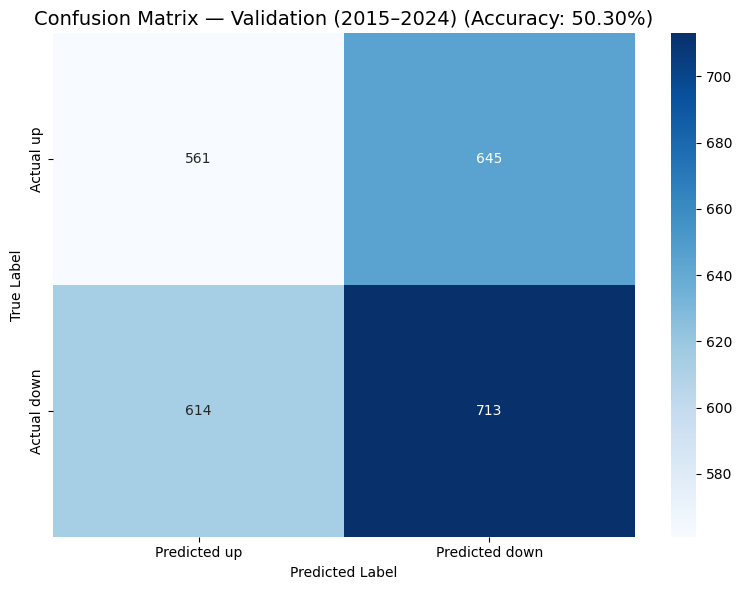

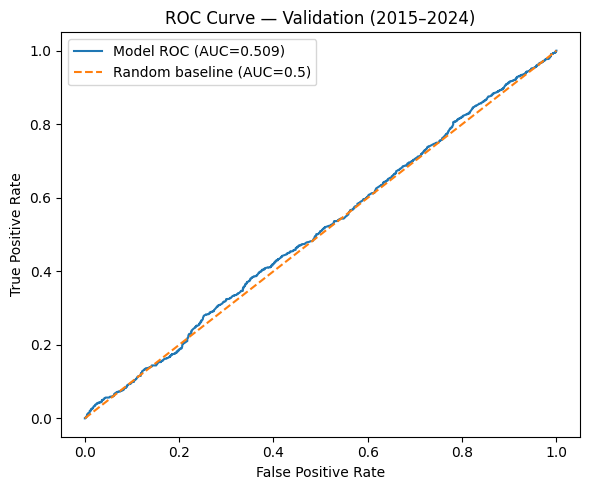

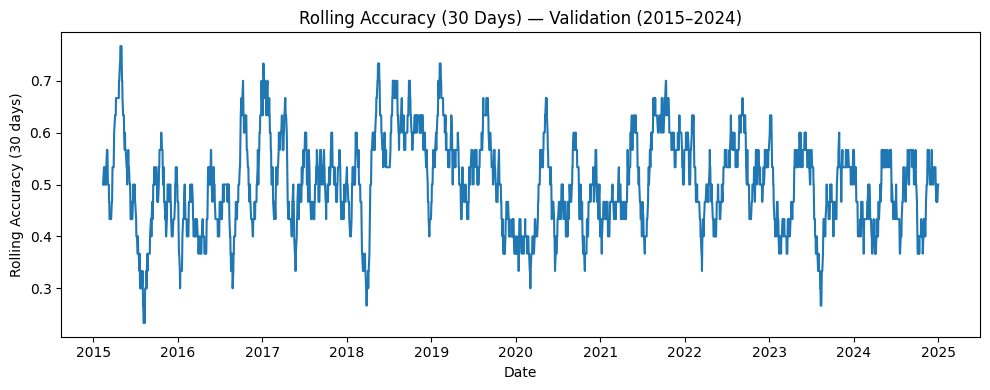

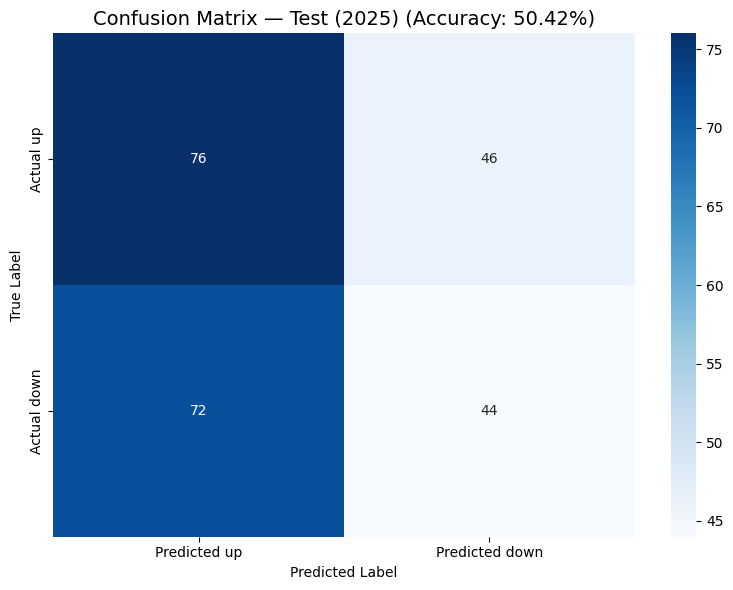

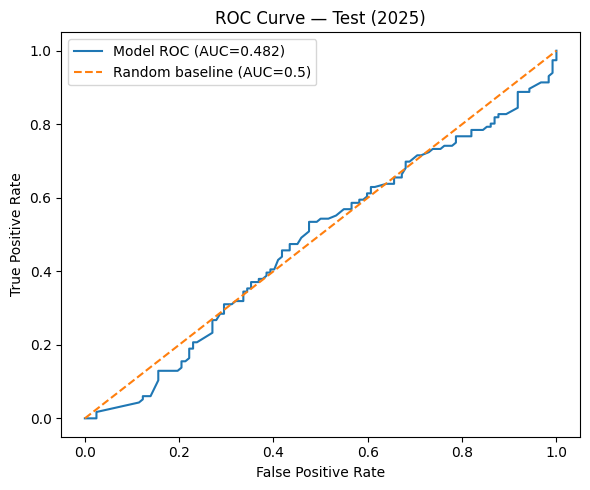

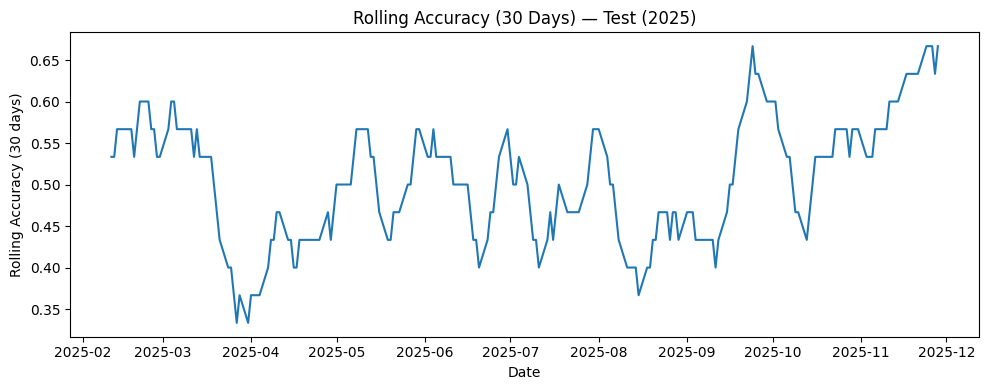


SAVE TRAINED MODEL
------------------------------------------------------------
Saved trained model: /content/drive/MyDrive/VIP_Energy_Market/lgbm_model.pkl


In [ ]:
def main() -> None:
    """
    Run the end-to-end LightGBM direction prediction workflow.
    """

    if OUT_ALIGNED.exists():
        aligned_df = pd.read_csv(OUT_ALIGNED, parse_dates=["Date"])
        print(f"Loaded existing aligned dataset: {OUT_ALIGNED} (rows={len(aligned_df)})")
    else:
        print("Aligned dataset not found. Building from raw inputs...")
        aligned_df = build_aligned_daily_dataset(
            oil_daily_csv=OIL_PATH,
            vintage_dirs=VINTAGE_DIRS,
            vintage_2025_csv=VINTAGE_FILE_25 if VINTAGE_FILE_25.exists() else None,
            out_csv=OUT_ALIGNED,
        )
        print(f"Saved aligned dataset: {OUT_ALIGNED} (rows={len(aligned_df)})")

    # --------------------------------------------------------
    # Create features and target
    # --------------------------------------------------------
    print("\nFEATURE ENGINEERING")
    print("-" * 60)

    feature_df = add_price_lags_and_target(aligned_df, lookback=LOOKBACK_DAYS)
    print(f"Rows after feature engineering: {len(feature_df)}")
    print(f"Total input features expected: {len(MACRO_31)} macro + {LOOKBACK_DAYS} price lags = {len(MACRO_31) + LOOKBACK_DAYS}")

    # --------------------------------------------------------
    # Time-based split
    # --------------------------------------------------------
    print("\nTIME-BASED SPLIT")
    print("-" * 60)

    splits = split_timewise(
        feature_df,
        train_end=TRAIN_END,
        val_end=VAL_END,
        test_end=TEST_END,
    )

    print(f"Train rows: {len(splits.train)}")
    print(f"Validation rows: {len(splits.val)}")
    print(f"Test rows: {len(splits.test)}")

    X_train, y_train, feature_cols = build_feature_matrix(splits.train, lookback=LOOKBACK_DAYS)
    X_val, y_val, _ = build_feature_matrix(splits.val, lookback=LOOKBACK_DAYS)
    X_test, y_test, _ = build_feature_matrix(splits.test, lookback=LOOKBACK_DAYS)

    # --------------------------------------------------------
    # Train the model
    # --------------------------------------------------------
    print("\nMODEL TRAINING")
    print("-" * 60)
    print("Training lgbm classifier with 5-fold TimeSeriesSplit on TRAIN only...")

    model = LGBMForecastModel(
    task_type="classification",
    n_splits=5,
    scoring="accuracy",
    random_state=42,
    n_estimators_grid=[100, 200, 300],
    learning_rate_grid=[0.01, 0.05, 0.1],
    max_depth_grid=[-1, 3, 5, 8],
    num_leaves_grid=[15, 31, 63],
)
    model.fit(X_train, y_train)

    print(f"Best hyperparameters: {model.best_params_}")
    print(f"Best CV score ({model.scoring}): {model.best_score_:.4f}")
    # --------------------------------------------------------
    # Validation evaluation
    # --------------------------------------------------------
    print("\nVALIDATION EVALUATION")
    print("-" * 60)

    y_val_pred = model.predict(X_val)
    y_val_prob = model.predict_proba(X_val)
    val_metrics = model.evaluate(X_val, y_val)
    # ==============================
    # THRESHOLD OPTIMIZATION (VALIDATION)
    # ==============================

    thresholds = np.linspace(0.3, 0.7, 41)

    best_acc = 0
    best_t = 0.5

    for t in thresholds:
       y_pred_val_t = (y_val_prob > t).astype(int)
       acc = accuracy_score(y_val, y_pred_val_t)
       if acc > best_acc:
           best_acc = acc
           best_t = t

    print(f"Best threshold from validation: {best_t:.3f}")
    print(f"Best validation accuracy: {best_acc:.4f}")
    print_metrics_block("VALIDATION (2015-2024)", val_metrics, y_val, y_val_pred)

    # --------------------------------------------------------
    # Test evaluation
    # --------------------------------------------------------
    print("\nTEST EVALUATION")
    print("-" * 60)

    y_test_prob = model.predict_proba(X_test)
    y_test_pred = model.predict(X_test)
    test_metrics = model.evaluate(X_test, y_test)
    print_metrics_block("TEST (2025)", test_metrics, y_test, y_test_pred)

    # --------------------------------------------------------
    # Required visualizations
    # --------------------------------------------------------
    print("\nVISUALIZATIONS")
    print("-" * 60)

    plot_confusion_matrix(
        y_val,
        y_val_pred,
        title="Confusion Matrix — Validation (2015–2024)",
        out_png=OUT_FIG_DIR / "cm_validation.png",
    )
    plot_roc_curve_with_baseline(
        y_val,
        y_val_prob,
        title="ROC Curve — Validation (2015–2024)",
        out_png=OUT_FIG_DIR / "roc_validation.png",
    )
    plot_rolling_accuracy(
        splits.val["Date"],
        y_val,
        y_val_pred,
        title="Rolling Accuracy (30 Days) — Validation (2015–2024)",
        out_png=OUT_FIG_DIR / "rolling_accuracy_validation.png",
    )

    plot_confusion_matrix(
        y_test,
        y_test_pred,
        title="Confusion Matrix — Test (2025)",
        out_png=OUT_FIG_DIR / "cm_test.png",
    )
    plot_roc_curve_with_baseline(
        y_test,
        y_test_prob,
        title="ROC Curve — Test (2025)",
        out_png=OUT_FIG_DIR / "roc_test.png",
    )
    plot_rolling_accuracy(
        splits.test["Date"],
        y_test,
        y_test_pred,
        title="Rolling Accuracy (30 Days) — Test (2025)",
        out_png=OUT_FIG_DIR / "rolling_accuracy_test.png",
    )

    # --------------------------------------------------------
    # Save fitted model
    # --------------------------------------------------------
    print("\nSAVE TRAINED MODEL")
    print("-" * 60)

    model.save(str(OUT_MODEL))
    print(f"Saved trained model: {OUT_MODEL}")
    return splits, y_test_pred, model, X_test

if __name__ == "__main__":
    splits, y_test_pred, model, X_test = main()


# Strategy 1: Threshold-Based Long-Short Trading Strategy

This strategy converts model prediction probabilities into discrete trading signals using upper and lower probability thresholds.

For each forecasting model, the probability of an upward WTI price movement is first generated using `predict_proba()`. The strategy then applies a quantile-based signal filtering approach:

- Long position (+1): prediction probability above the 70th percentile
- Short position (-1): prediction probability below the 30th percentile
- Neutral position (0): otherwise

This framework attempts to trade only when the model produces relatively confident directional forecasts while avoiding weak or uncertain market signals.

Daily strategy returns are calculated by multiplying the trading signal with the actual daily WTI return. The cumulative portfolio return is then computed over the entire 2025 test period.

Finally, the cumulative returns of all four forecasting models are compared against a buy-and-hold benchmark strategy.

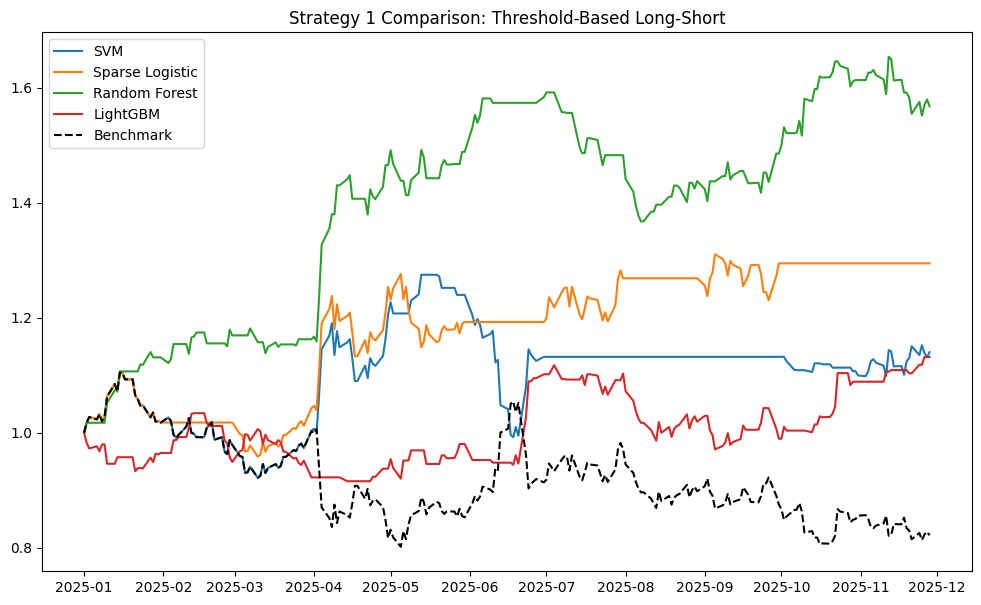


=== Strategy 1: Performance Comparison ===
                 Total Return  Annual Return  Volatility    Sharpe  Max Drawdown  Win Rate  Trades  Exposure
Benchmark           -0.178246      -0.187681    0.316267 -0.593425     -0.274171  0.487395     0.0  1.000000
SVM                  0.140303       0.149144    0.261073  0.571273     -0.221448  0.285714    22.0  0.605042
Sparse Logistic      0.294849       0.314680    0.231693  1.358180     -0.132410  0.298319     8.0  0.558824
Random Forest        0.567884       0.609915    0.216608  2.815760     -0.140883  0.323529    94.0  0.605042
LightGBM             0.131941       0.140224    0.218834  0.640776     -0.131090  0.294118    88.0  0.592437


In [ ]:
import joblib
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Setup paths and load models
base_path = '/content/drive/MyDrive/VIP_Energy_Market/'
model_mapping = {
    "SVM": base_path + "svc_model.pkl",
    "Sparse Logistic": base_path + "sparse_logistic_direction_model.pkl",
    "Random Forest": base_path + "tree_forecast_model.pkl",
    "LightGBM": base_path + "lgbm_model.pkl"
}

loaded_models = {}
for name, path in model_mapping.items():
    if os.path.exists(path):
        obj = joblib.load(path)
        loaded_models[name] = obj['model'] if isinstance(obj, dict) and 'model' in obj else obj

# 2. Prepare data
results_df = splits.test.copy()
results_df['Actual_Return'] = results_df['Price'].pct_change().fillna(0)
results_df['Benchmark_Cum'] = (1 + results_df['Actual_Return']).cumprod()

def compute_metrics(returns, positions):
    returns = pd.Series(returns).fillna(0)
    cumulative = (1 + returns).cumprod()

    total_return = cumulative.iloc[-1] - 1
    annual_return = (1 + total_return) ** (252 / len(returns)) - 1
    volatility = returns.std() * np.sqrt(252)
    sharpe = annual_return / volatility if volatility > 0 else np.nan

    running_max = cumulative.cummax()
    drawdown = cumulative / running_max - 1
    max_dd = drawdown.min()

    win_rate = (returns > 0).mean()
    trades = (pd.Series(positions).diff().fillna(0) != 0).sum()
    exposure = (pd.Series(positions) != 0).mean()

    return {
        "Total Return": total_return,
        "Annual Return": annual_return,
        "Volatility": volatility,
        "Sharpe": sharpe,
        "Max Drawdown": max_dd,
        "Win Rate": win_rate,
        "Trades": trades,
        "Exposure": exposure
    }
# 3. Execution and Metrics Calculation
all_metrics = {}

# Calculate Benchmark Metrics first
all_metrics['Benchmark'] = compute_metrics(results_df['Actual_Return'], np.ones(len(results_df)))

plt.figure(figsize=(12, 7))

for name, mdl in loaded_models.items():
    try:
        y_prob = mdl.predict_proba(X_test)
        if y_prob.ndim > 1:
            y_prob = y_prob[:, 1]

        u_thresh = np.quantile(y_prob, 0.7)
        l_thresh = np.quantile(y_prob, 0.3)
        signals = np.where(y_prob > u_thresh, 1, np.where(y_prob < l_thresh, -1, 0))

        strat_ret = signals * results_df['Actual_Return']
        results_df[f'{name}_Cum'] = (1 + strat_ret).cumprod()

        # Store metrics
        all_metrics[name] = compute_metrics(strat_ret, signals)

        plt.plot(results_df['Date'], results_df[f'{name}_Cum'], label=name)
    except Exception as e:
        print(f"Error processing {name}: {e}")

# 4. Finalize Plot
plt.plot(results_df['Date'], results_df['Benchmark_Cum'], label='Benchmark', color='black', linestyle='--')
plt.title('Strategy 1 Comparison: Threshold-Based Long-Short')
plt.legend()
plt.show()

# 5. Print Metrics Table
metrics_final_df = pd.DataFrame(all_metrics).T
print("\n=== Strategy 1: Performance Comparison ===")
print(metrics_final_df.to_string())

# Strategy 2: Probability-Weighted Trading Strategy

The second investment strategy uses a probability-weighted position sizing framework designed to generate more dynamic market exposure and potentially higher returns.

Instead of converting prediction probabilities into discrete long-short signals, the strategy directly maps model confidence into continuous trading positions. For each forecasting model, the probability of an upward WTI price movement is obtained using `predict_proba()`.

Position sizes are calculated using the following mapping:

Position = (Predicted Probability − 0.5) × 4

This aggressive scaling amplifies high-confidence signals and increases market exposure when the model produces stronger directional forecasts.

To prevent excessive leverage and risk concentration, all positions are clipped within the range:

- Maximum long exposure: +1.5
- Maximum short exposure: −1.5

Daily trading returns are computed by multiplying the weighted position size with the actual daily WTI return. The cumulative portfolio return is then calculated over the full 2025 test period.

Compared with Strategy 1, this framework maintains continuous market exposure and reacts more aggressively to changing prediction probabilities. While this may improve return potential, it also increases volatility and sensitivity to forecasting errors.

Finally, the cumulative returns of all four forecasting models are compared against the benchmark buy-and-hold strategy.

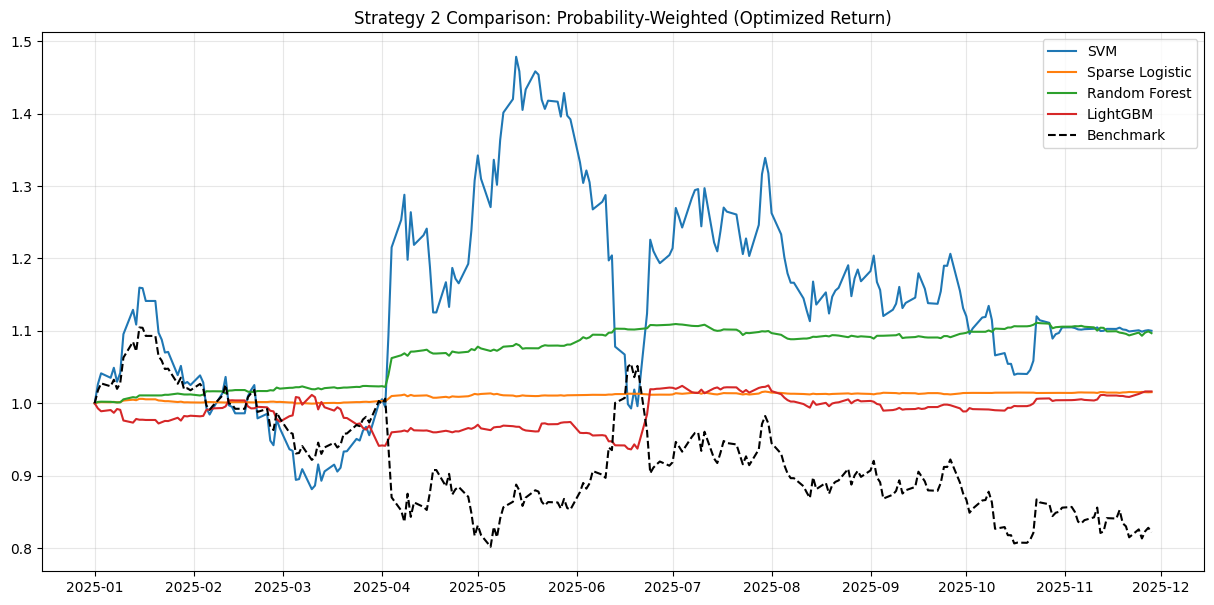


=== Strategy 2: Performance Comparison ===
                 Total Return  Annual Return  Volatility    Sharpe  Max Drawdown  Win Rate  Trades  Exposure
Benchmark           -0.178246      -0.187681    0.316267 -0.593425     -0.274171  0.487395     0.0       1.0
SVM                  0.100135       0.106329    0.448236  0.237216     -0.328523  0.487395    69.0       1.0
Sparse Logistic      0.015384       0.016296    0.011937  1.365170     -0.006576  0.512605    10.0       1.0
Random Forest        0.096874       0.102856    0.041504  2.478245     -0.018942  0.512605   237.0       1.0
LightGBM             0.016351       0.017321    0.098915  0.175112     -0.074360  0.487395   177.0       1.0


In [ ]:
# === Strategy 2: Performance Comparison (Optimized for High Return) ===

# 1. Prepare data: Ensure actual_returns are aligned with test prices to maintain benchmark integrity
actual_returns = splits.test['Price'].pct_change().fillna(0)
results_s2 = pd.DataFrame({'Date': splits.test['Date'], 'Benchmark_Ret': actual_returns})
results_s2['Benchmark_Cum'] = (1 + results_s2['Benchmark_Ret']).cumprod()

all_metrics_s2 = {}
# Calculate Benchmark performance metrics as the baseline
all_metrics_s2['Benchmark'] = compute_metrics(results_s2['Benchmark_Ret'], np.ones(len(results_s2)))

plt.figure(figsize=(15, 7))

# 2. Iterate through the four models for comparison
model_names = ["SVM", "Sparse Logistic", "Random Forest", "LightGBM"]

for name in model_names:
    if name in loaded_models:
        try:
            mdl = loaded_models[name]
            y_prob = mdl.predict_proba(X_test)
            # Extract probability for the positive class (price up)
            if y_prob.ndim > 1:
                y_prob = y_prob[:, 1]

            # --- Core Logic for Return Optimization ---
            # Increase the slope from 2 to 4 for an aggressive mapping.
            # This amplifies high-confidence signals to capture excess returns.
            pos = (y_prob - 0.5) * 4
            # Implement a position cap (leverage) of 1.5x to manage extreme exposure
            pos = np.clip(pos, -1.5, 1.5)

            # Calculate daily strategy returns and cumulative performance
            strat_ret = pos * actual_returns
            results_s2[f'{name}_Cum'] = (1 + strat_ret).cumprod()

            # Store metrics for each individual model strategy
            all_metrics_s2[name] = compute_metrics(strat_ret, pos)

            # Plotting: Color-coded solid lines for model strategies
            plt.plot(results_s2['Date'], results_s2[f'{name}_Cum'], label=name)
        except Exception as e:
            print(f"Error processing {name} in Strategy 2: {e}")

# 3. Plot Benchmark: Black dashed line for clear visual distinction
plt.plot(results_s2['Date'], results_s2['Benchmark_Cum'], label='Benchmark', color='black', linestyle='--')

# 4. Finalize visualization parameters
plt.title('Strategy 2 Comparison: Probability-Weighted (Optimized Return)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. Print Metrics Table for detailed performance analysis
metrics_s2_df = pd.DataFrame(all_metrics_s2).T
print("\n=== Strategy 2: Performance Comparison ===")
print(metrics_s2_df.to_string())